In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/karyo-wise

/content/drive/MyDrive/karyo-wise


In [3]:
!pip install -r requirements.txt

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-_6cgwolp
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-_6cgwolp
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
Obtaining file:///content/drive/MyDrive/karyo-wise (from -r requirements.txt (line 28))
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━

In [10]:
from tqdm import tqdm
import shutil
from pathlib import Path

import cv2
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# import torch

--- Logging error in Loguru Handler #1 ---
Record was: {'elapsed': datetime.timedelta(seconds=2552, microseconds=267913), 'exception': None, 'extra': {}, 'file': (name='config.py', path='/content/drive/MyDrive/karyo-wise/karyo_wise/config.py'), 'function': '<module>', 'level': (name='INFO', no=20, icon='ℹ️'), 'line': 11, 'message': 'PROJ_ROOT path is: /content/drive/MyDrive/karyo-wise', 'module': 'config', 'name': 'karyo_wise.config', 'process': (id=756, name='MainProcess'), 'thread': (id=134948451438592, name='MainThread'), 'time': datetime(2024, 10, 16, 3, 13, 45, 284437, tzinfo=datetime.timezone(datetime.timedelta(0), 'UTC'))}
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/loguru/_handler.py", line 206, in emit
    self._sink.write(str_record)
  File "/usr/local/lib/python3.10/dist-packages/loguru/_simple_sinks.py", line 122, in write
    self._function(message)
  File "/content/drive/MyDrive/karyo-wise/karyo_wise/config.py", line 53, in <lambda>


In [12]:
%reload_ext autoreload
%autoreload 2
import karyo_wise.config as config
import karyo_wise.plots as plots
import karyo_wise.dataset as dataset

In [13]:
!ls {config.TEST_DATA_CSV}

/content/drive/MyDrive/karyo-wise/data/processed/seg_test_data.csv


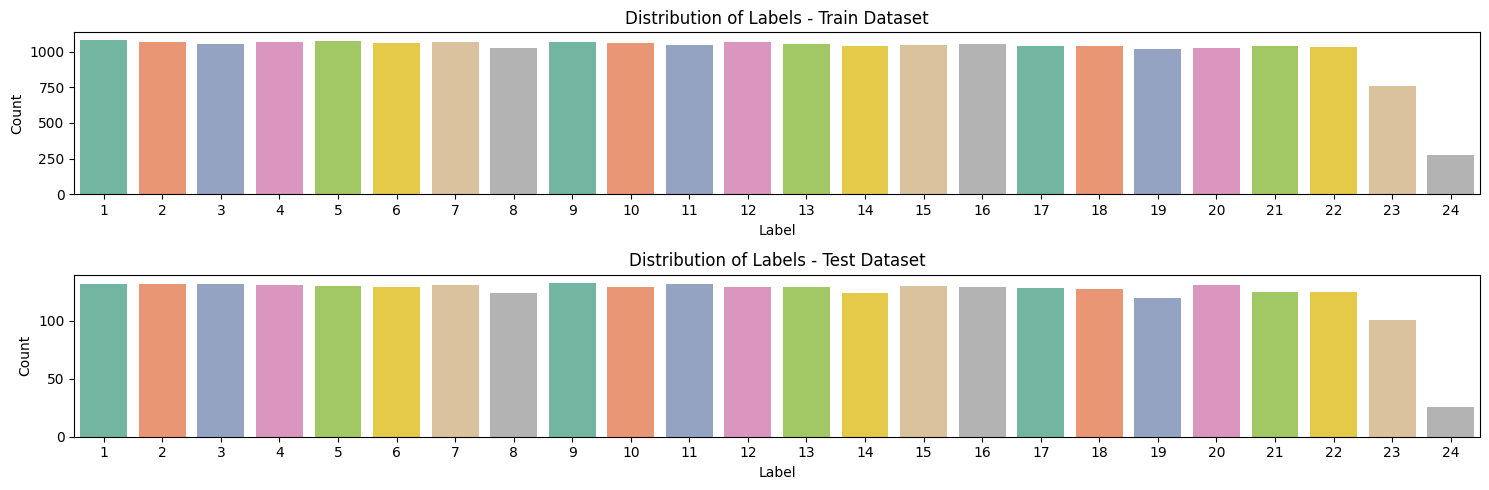

In [14]:
labels_plot = plots.plot_label_distributions()

In [9]:
!ls {Config.PROCESSED_DATA_DIR_TEST_MASKS}

0_1_247_180_0.462_mask.png     183_1_394_477_0.851_mask.png   298_1_1129_642_0.675_mask.png
0_2_247_180_0.720_mask.png     196_2_1031_477_0.524_mask.png  30_1_737_213_0.864_mask.png
101_1_296_345_0.638_mask.png   197_1_1080_477_0.927_mask.png  31_4_786_213_0.779_mask.png
106_6_541_345_0.849_mask.png   202_3_345_510_0.575_mask.png   32_1_835_213_0.523_mask.png
112_2_835_345_0.704_mask.png   209_2_688_510_0.628_mask.png   40_4_247_246_0.838_mask.png
114_6_933_345_0.825_mask.png   210_4_737_510_0.894_mask.png   42_6_345_246_0.505_mask.png
116_2_1031_345_0.496_mask.png  217_2_1080_510_0.849_mask.png  51_2_786_246_0.741_mask.png
116_3_1031_345_0.609_mask.png  218_5_1129_510_0.594_mask.png  52_3_835_246_0.484_mask.png
122_1_345_378_0.876_mask.png   220_5_247_543_0.540_mask.png   54_2_933_246_0.867_mask.png
126_2_541_378_0.605_mask.png   223_1_394_543_0.476_mask.png   56_1_1031_246_0.913_mask.png
129_1_688_378_0.461_mask.png   224_2_443_543_0.618_mask.png   62_2_345_279_0.701_mask.png
130_1_7

In [ ]:
from pathlib import Path
import typer
from os.path import splitext, isfile, join
from loguru import logger
from tqdm import tqdm

from torch.utils.data import Dataset

"""
    Class that defines the reading and processing of the images
"""
class MetaphaseDataset(Dataset):
  def __init__(self, images_dir: str, mask_dir: str):
    self.images_dir = Path(images_dir)
    self.mask_dir = Path(mask_dir)
    self.ids = [file[-8:] for file in self.images_dir.iterdir() if isfile(images_dir / file)]


In [15]:
images_dir = Path(config.PROCESSED_DATA_DIR_TRAIN_IMG)
ids = [file[-8:] for file in config.iterdir() if isfile(images_dir / file)]

NameError: name 'self' is not defined